In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/processed/cleaned_data.csv")
df.head()

,diseases,anxiety_and_nervousness,depression,shortness_of_breath,depressive_or_psychotic_symptoms,sharp_chest_pain,dizziness,insomnia,abnormal_involuntary_movements,chest_tightness,...,redness_in_or_around_nose,wrinkles_on_skin,foot_or_toe_weakness,hand_or_finger_cramps_or_spasms,back_stiffness_or_tightness,wrist_lump_or_mass,skin_pain,low_urine_output,sore_in_nose,ankle_weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(189640, 329)

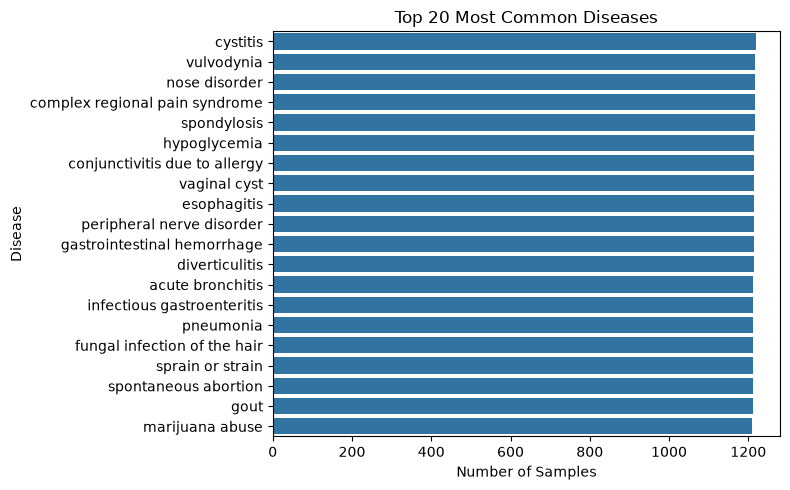

In [12]:
plt.figure(figsize=(8,5))

top_diseases = df['diseases'].value_counts().head(20)

sns.barplot(
    x=top_diseases.values,
    y=top_diseases.index
)
plt.title("Top 20 Most Common Diseases")
plt.xlabel("Number of Samples")
plt.ylabel("Disease")
plt.tight_layout()
plt.show()

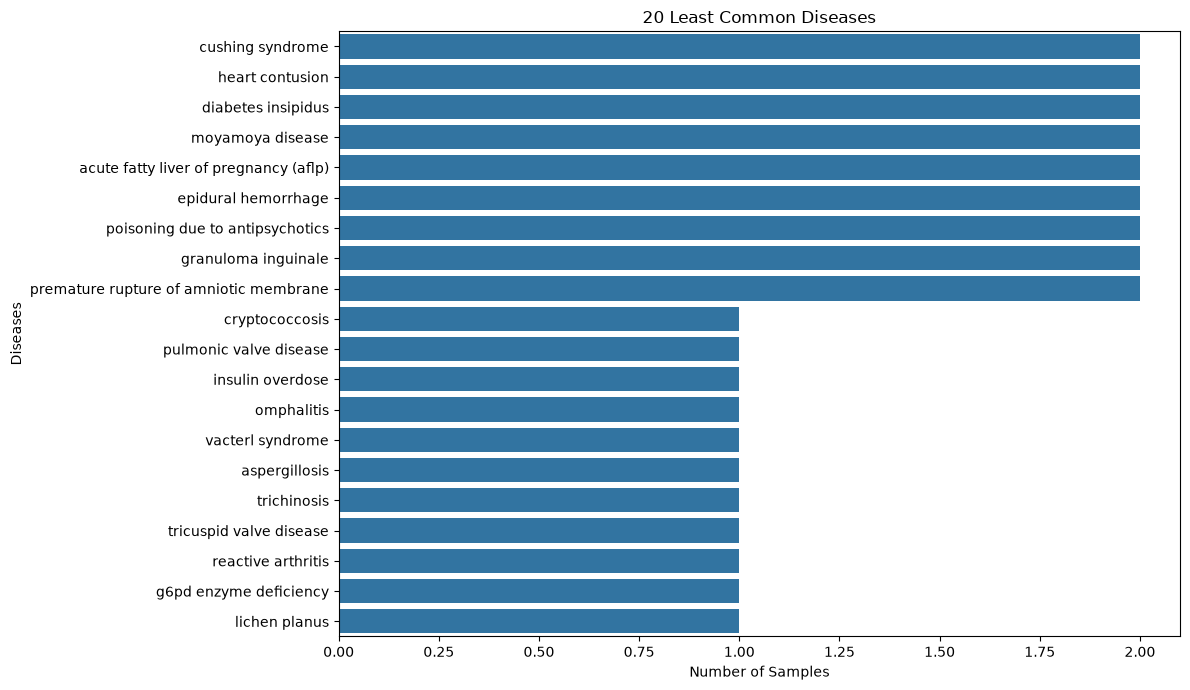

In [13]:
plt.figure(figsize=(12, 7))
bottom_diseases = df['diseases'].value_counts().tail(20)

sns.barplot(
    x=bottom_diseases.values,
    y=bottom_diseases.index
)
plt.title("20 Least Common Diseases")
plt.xlabel("Number of Samples")
plt.ylabel("Diseases")
plt.tight_layout()
plt.show()

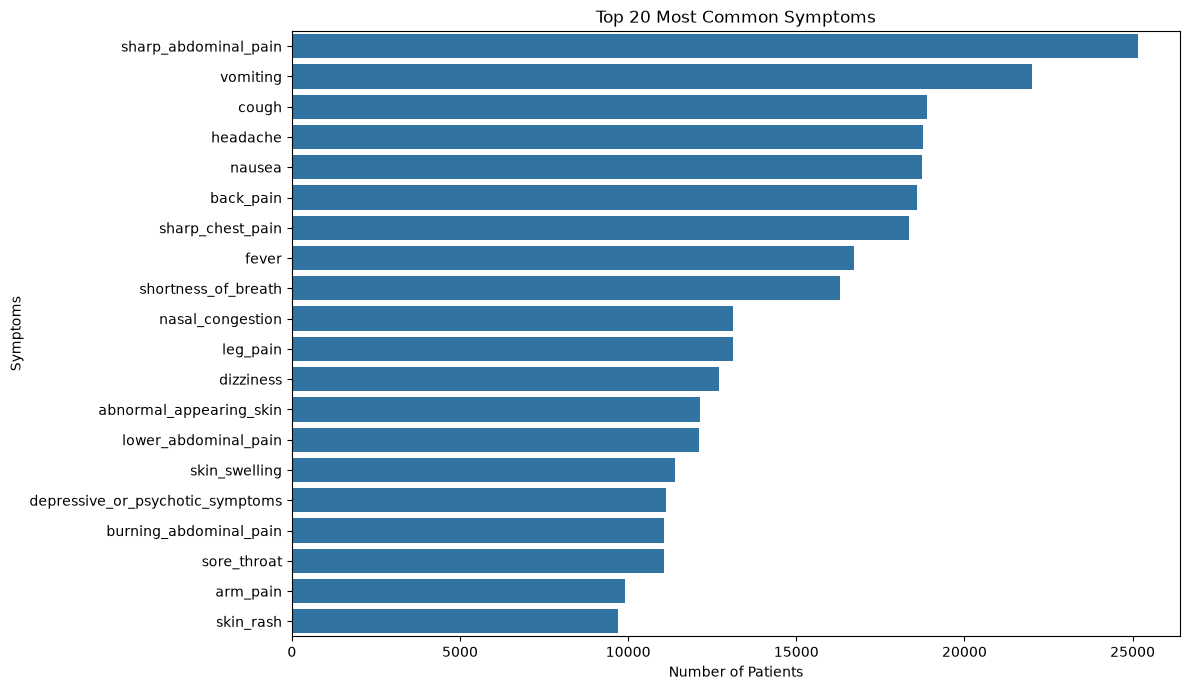

In [15]:
plt.figure(figsize=(12, 7))
top_symptoms = (
    df.drop(columns="diseases").sum().sort_values(ascending=False).head(20)
)

sns.barplot(
    x=top_symptoms.values,
    y=top_symptoms.index
)
plt.title("Top 20 Most Common Symptoms")
plt.xlabel("Number of Patients")
plt.ylabel("Symptoms")
plt.tight_layout()
plt.show()

In [16]:
# Top 10 most common diseases

selected_diseases = (
    df["diseases"].value_counts().head(10).index
)

# Top 15 most common symptoms

selected_symptoms = (
    df.drop(columns="diseases").sum().sort_values(ascending=False).head(15).index
)

print("Selected Diseases:")
print(selected_diseases)

print("\nSelected Symptoms:")
print(selected_symptoms)

Selected Diseases:
Index(['cystitis', 'vulvodynia', 'nose disorder',
       'complex regional pain syndrome', 'spondylosis', 'hypoglycemia',
       'conjunctivitis due to allergy', 'vaginal cyst', 'esophagitis',
       'peripheral nerve disorder'],
      dtype='str', name='diseases')

Selected Symptoms:
Index(['sharp_abdominal_pain', 'vomiting', 'cough', 'headache', 'nausea',
       'back_pain', 'sharp_chest_pain', 'fever', 'shortness_of_breath',
       'nasal_congestion', 'leg_pain', 'dizziness', 'abnormal_appearing_skin',
       'lower_abdominal_pain', 'skin_swelling'],
      dtype='str')


In [17]:
disease_symptoms = (
    df[df["diseases"].isin(selected_diseases)]
    .groupby("diseases")[selected_symptoms].mean()
)
disease_symptoms

,sharp_abdominal_pain,vomiting,cough,headache,nausea,back_pain,sharp_chest_pain,fever,shortness_of_breath,nasal_congestion,leg_pain,dizziness,abnormal_appearing_skin,lower_abdominal_pain,skin_swelling
diseases,,,,,,,,,,,,,,,
complex regional pain syndrome,0.000000,0.000000,0.000000,0.000000,0.000000,0.533279,0.000000,0.000000,0.000000,0.000000,0.506163,0.000000,0.0,0.000000,0.0
conjunctivitis due to allergy,0.000000,0.000000,0.474074,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.514403,0.000000,0.000000,0.0,0.000000,0.0
cystitis,0.499590,0.000000,0.000000,0.000000,0.000000,0.481542,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.502871,0.0
esophagitis,0.490535,0.517695,0.503704,0.000000,0.502881,0.000000,0.502881,0.000000,0.474074,0.000000,0.000000,0.000000,0.0,0.000000,0.0
hypoglycemia,0.000000,0.000000,0.000000,0.000000,0.513580,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.499588,0.0,0.000000,0.0
nose disorder,0.000000,0.000000,0.505747,0.498358,0.000000,0.000000,0.000000,0.495074,0.000000,0.499179,0.000000,0.000000,0.0,0.000000,0.0
peripheral nerve disorder,0.000000,0.000000,0.000000,0.000000,0.000000,0.508642,0.000000,0.000000,0.000000,0.000000,0.503704,0.475720,0.0,0.000000,0.0
spondylosis,0.000000,0.000000,0.000000,0.000000,0.000000,0.510691,0.000000,0.000000,0.000000,0.000000,0.480263,0.000000,0.0,0.000000,0.0
vaginal cyst,0.478189,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.511934,0.0


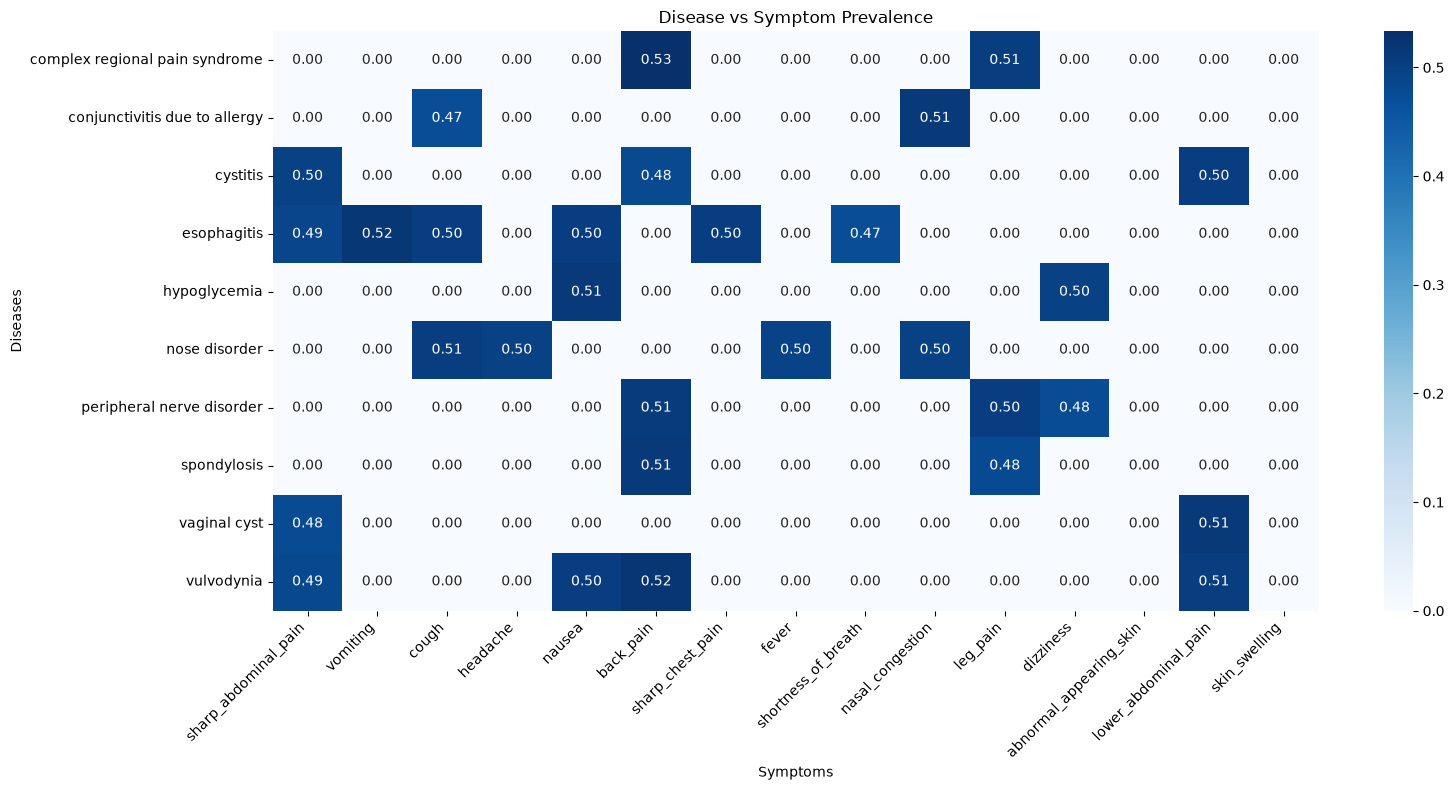

In [19]:
plt.figure(figsize=(16, 8))

sns.heatmap(
    disease_symptoms,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Disease vs Symptom Prevalence")
plt.xlabel("Symptoms")
plt.ylabel("Diseases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [25]:
disease = "panic disorder"

disease_data = df[df["diseases"] == disease]

symptom_counts = (
    disease_data
    .drop(columns="diseases")
    .sum()
    .sort_values(ascending=False)
)

print(f"Top sympptoms associated with {disease}:")
print(symptom_counts.head(11))

Top sympptoms associated with panic disorder:
depressive_or_psychotic_symptoms    521
dizziness                           424
abnormal_involuntary_movements      417
insomnia                            417
breathing_fast                      413
chest_tightness                     411
anxiety_and_nervousness             406
palpitations                        401
irregular_heartbeat                 401
shortness_of_breath                 400
depression                          398
dtype: int64


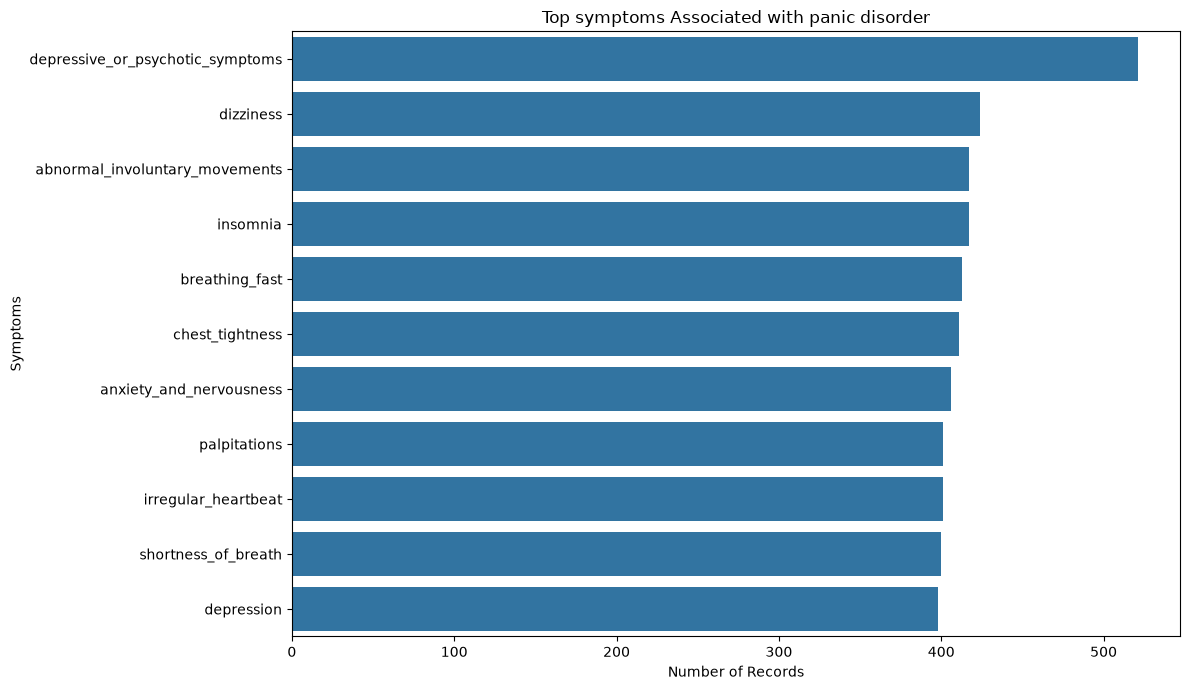

In [26]:
top_symptoms = symptom_counts.head(11)

plt.figure(figsize=(12, 7))
sns.barplot(
    x= top_symptoms.values,
    y= top_symptoms.index
)

plt.title(f"Top symptoms Associated with {disease}")
plt.xlabel("Number of Records")
plt.ylabel("Symptoms")
plt.tight_layout()
plt.show()